In [2]:
# Load dataset
df = pd.read_csv('country_wise_latest.csv')

# Check for missing values
print(df.isnull().sum())  # ✅ No null values found

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64


COVID-19 DATA ANALYSIS - UNSUPERVISED LEARNING

Dataset Shape: (187, 15)
Features: ['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'Confirmed last week', '1 week change', '1 week % increase', 'WHO Region']

--- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    str    
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Death

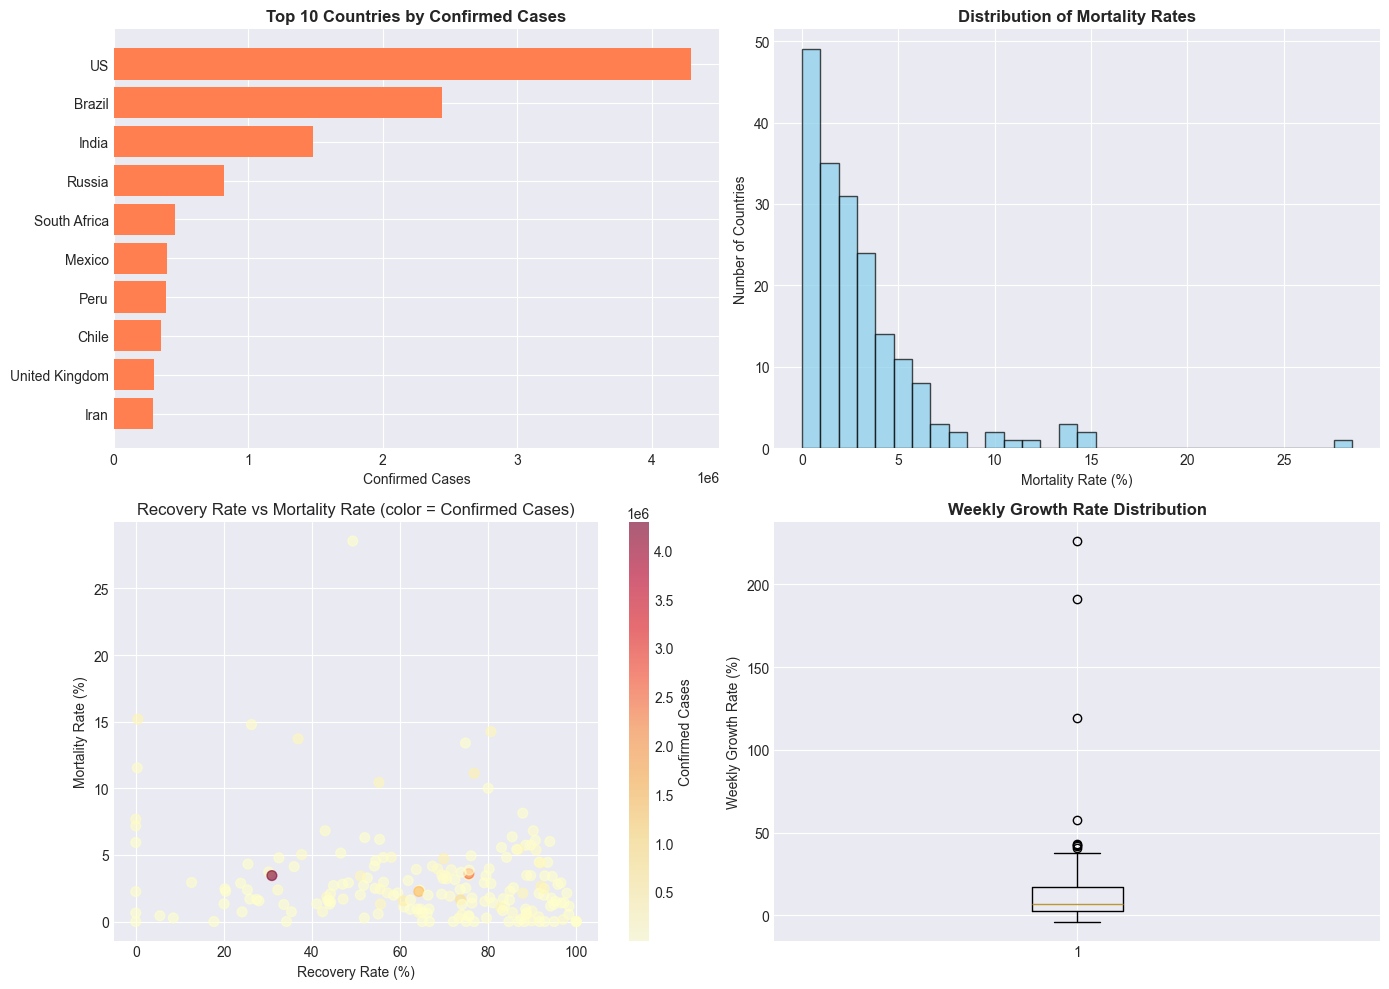


FEATURE SCALING
Original data shape: (187, 10)
Scaled data shape: (187, 10)
Scaling methods applied: StandardScaler, MinMaxScaler

K-MEANS CLUSTERING ANALYSIS

--- Optimal Number of Clusters (by Silhouette Score): 2 ---
Best Silhouette Score: 0.8191


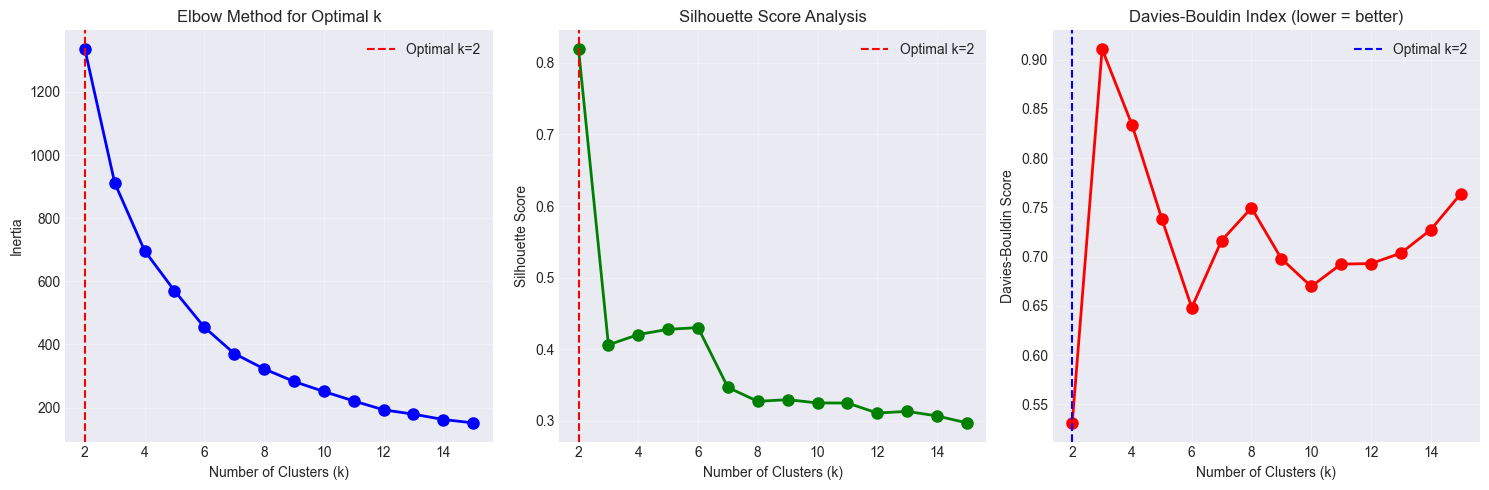


--- K-Means Cluster Analysis ---
                 Confirmed           Deaths Recovery_Rate Mortality_Rate  \
                      mean count       mean          mean           mean   
KMeans_Cluster                                                             
0                 52691.09   185    2261.66          0.65           0.03   
1               3366317.00     2  117814.50          0.53           0.04   

               1 week % increase  
                            mean  
KMeans_Cluster                    
0                          13.61  
1                          13.58  

--- Sample Countries per Cluster ---
Cluster 0: ['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola']
Cluster 1: ['Brazil', 'US']

HIERARCHICAL CLUSTERING ANALYSIS


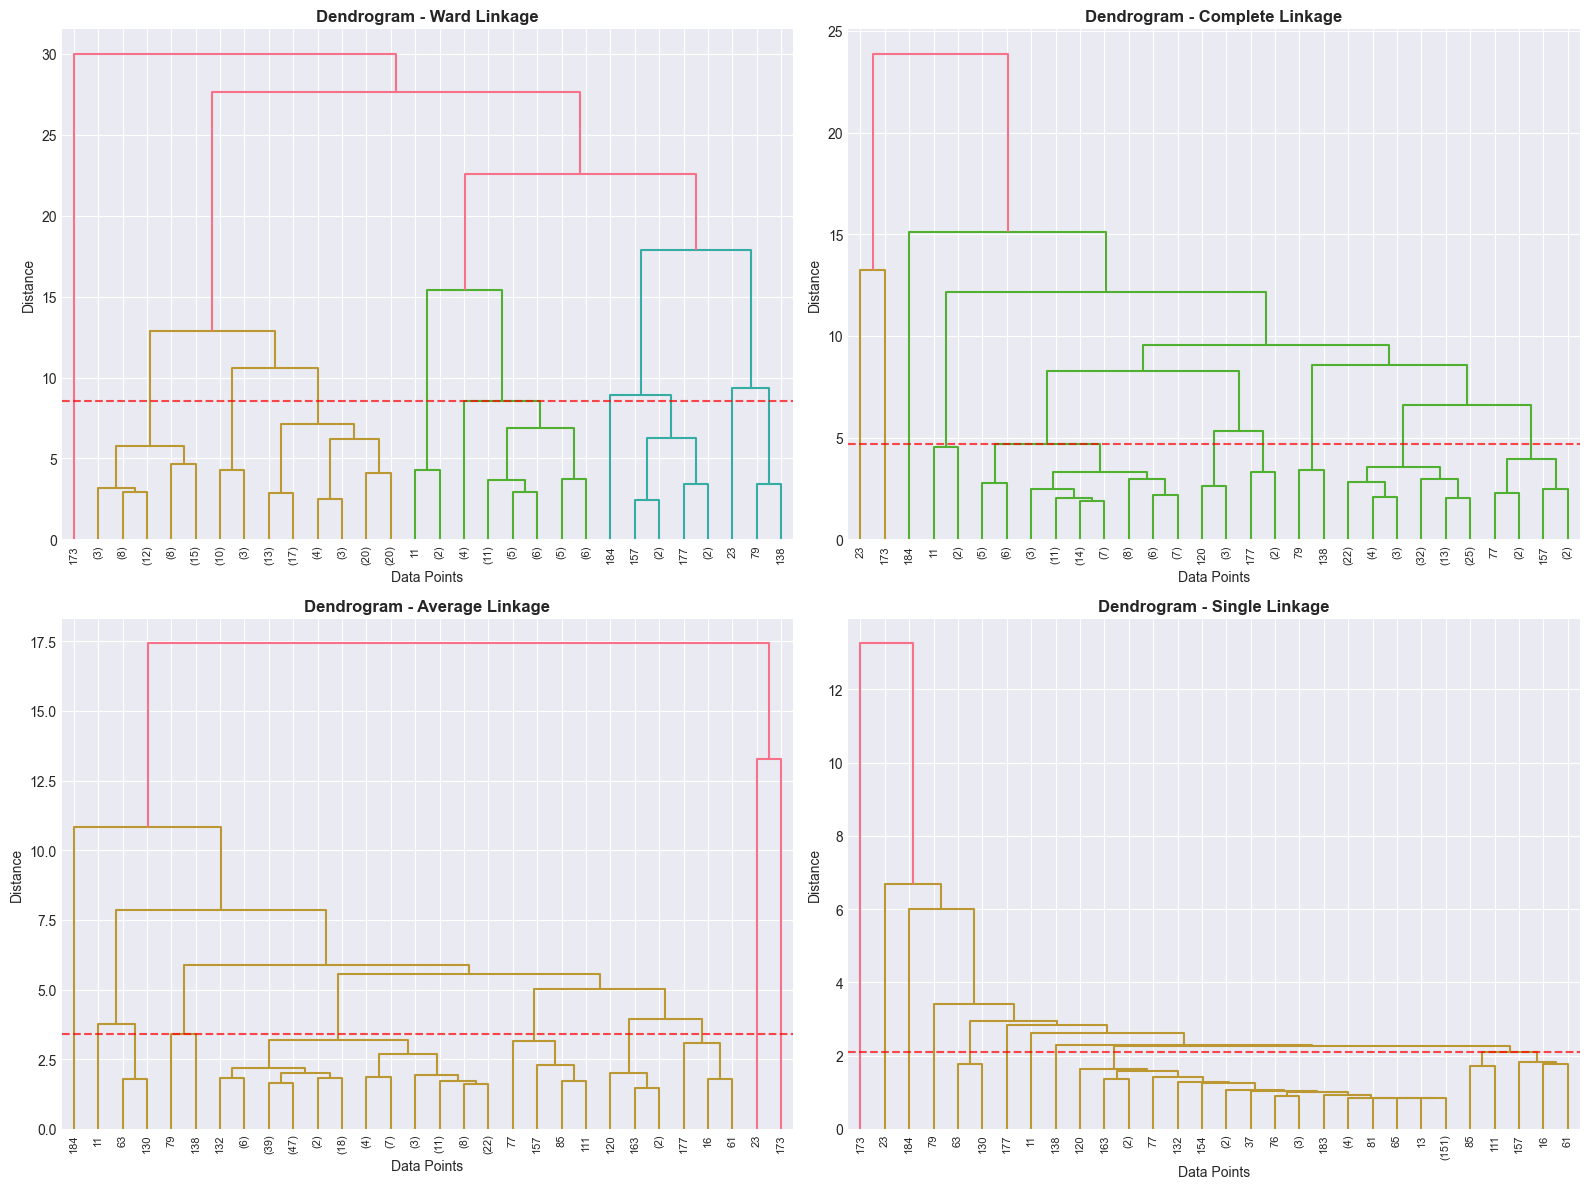


--- Optimal Number of Clusters (from silhouette): 2 ---
Best Silhouette Score: 0.8468

--- Hierarchical Cluster Analysis ---
                       Confirmed           Deaths Recovery_Rate Mortality_Rate
                            mean count       mean          mean           mean
Hierarchical_Cluster                                                          
1                       65538.85   186    2720.56          0.65           0.03
2                     4290259.00     1  148011.00          0.31           0.03

DBSCAN CLUSTERING ANALYSIS

--- Best DBSCAN Parameters ---
Epsilon (eps): 1.800
Min Samples: 2
Silhouette Score: 0.4834

--- DBSCAN Results ---
Number of clusters: 4
Number of noise points: 8
Percentage of noise: 4.28%

--- DBSCAN Cluster Summary ---

Noise Points (8 countries):
  Examples: ['Bahamas', 'Brazil', 'India', 'Russia', 'Spain', 'US', 'United Kingdom', 'Yemen']

Cluster 0 (173 countries):
  Avg Confirmed: 34370
  Avg Mortality Rate: 2.54%
  Avg Recovery Rate: 66.

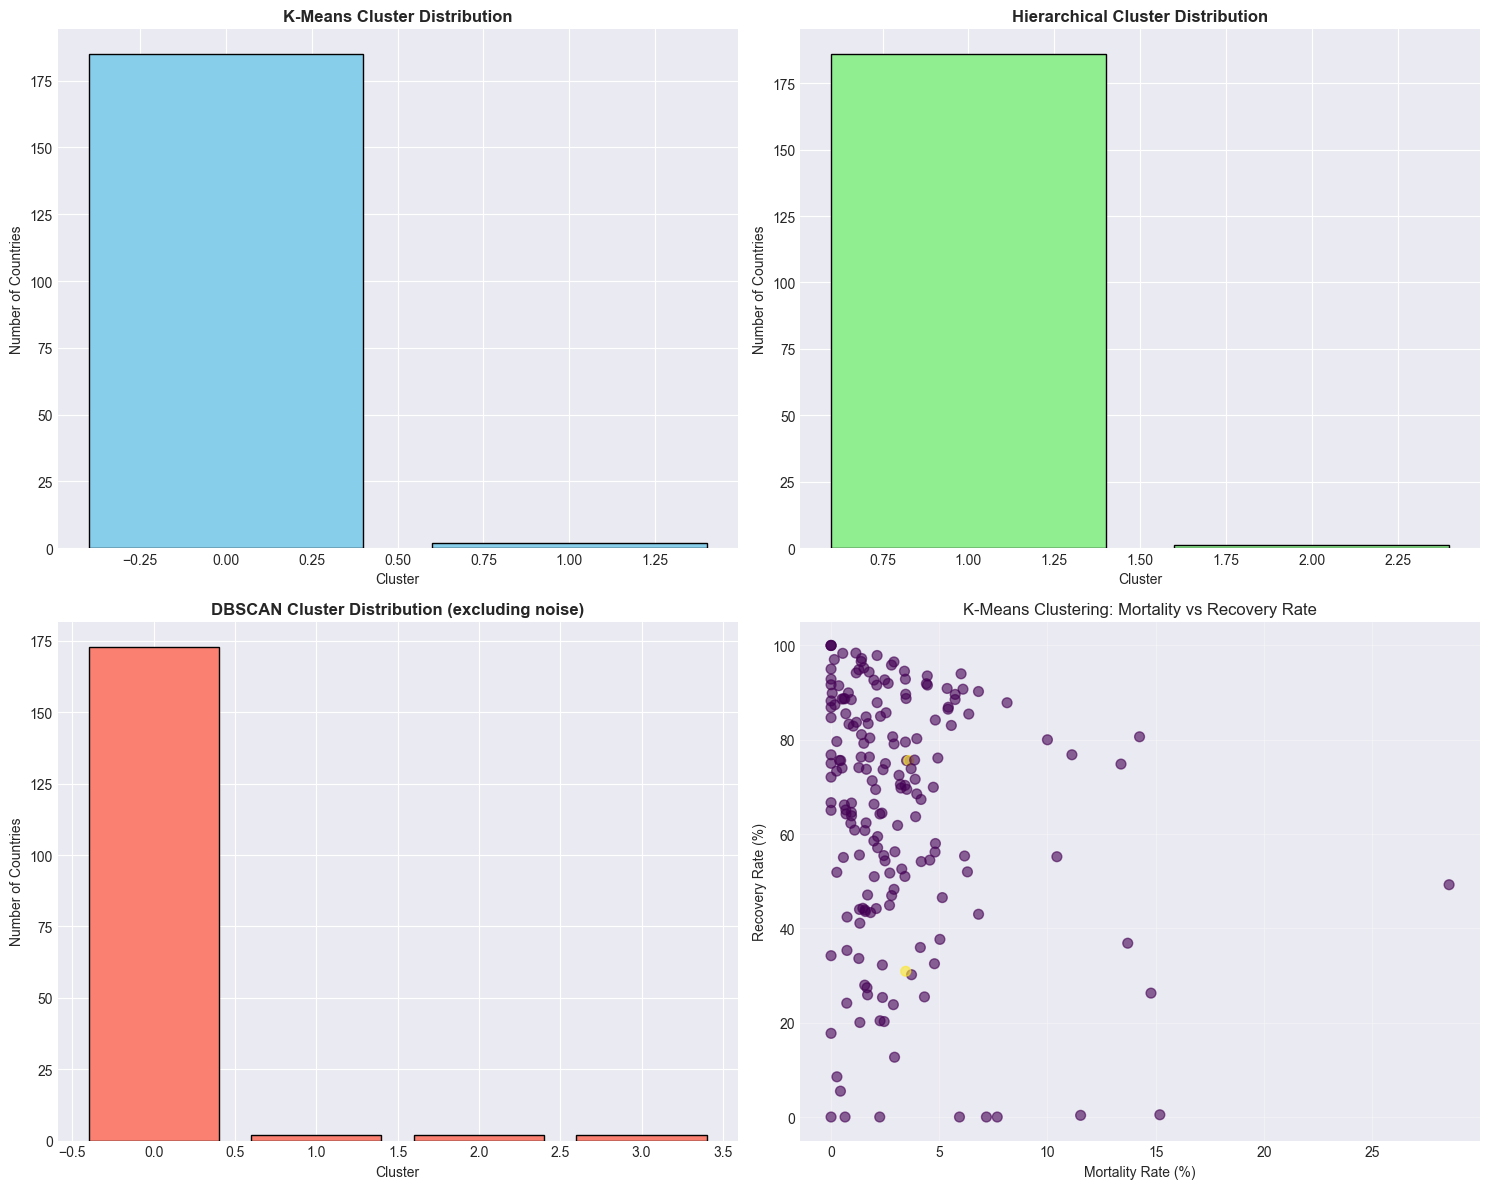


--- K-Means Cluster Characteristics ---
                Avg Confirmed  Avg Mortality Rate  Avg Recovery Rate  \
KMeans_Cluster                                                         
0                5.269109e+04              0.0301             0.6495   
1                3.366317e+06              0.0352             0.5326   

                Avg Weekly Growth  
KMeans_Cluster                     
0                         13.6065  
1                         13.5800  

2D VISUALIZATION OF CLUSTERING RESULTS
PCA Explained Variance Ratio: [0.376926   0.31285022]
Total variance explained: 68.98%
An error occurred: 'Hierarchical_Cluster'


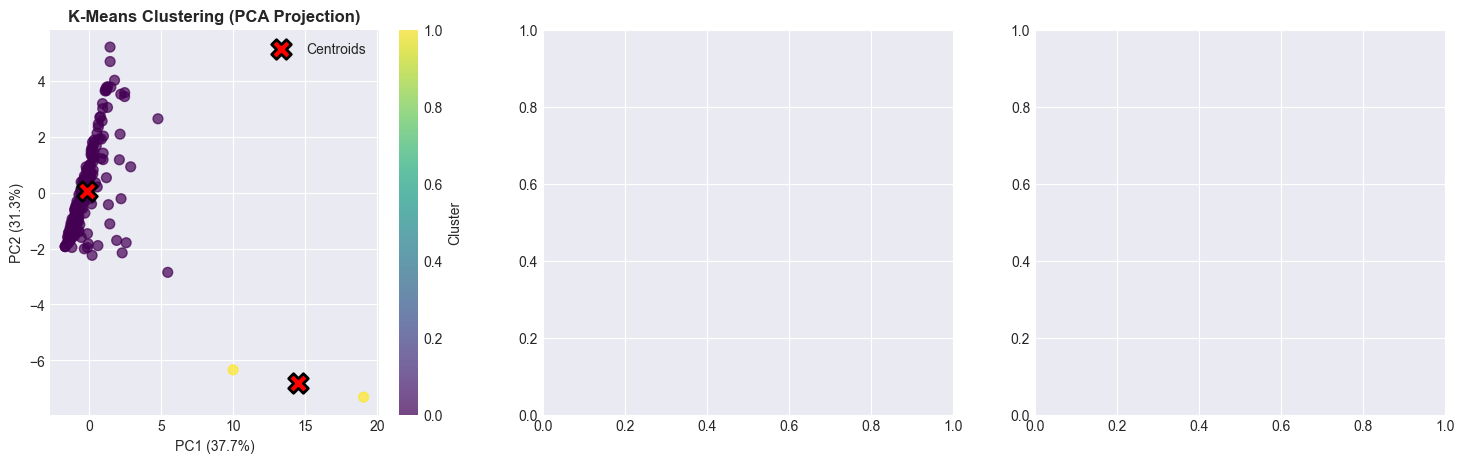

In [4]:
"""
COVID-19 Country-Wise Analysis
Unsupervised Machine Learning Project
Author: Data Science Professional
Date: June 2026
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

# Set style for professional visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

def load_and_preprocess_data(filepath):
    """Load and preprocess the COVID-19 dataset"""
    
    # Load data
    df = pd.read_csv(filepath)
    
    print("=" * 80)
    print("COVID-19 DATA ANALYSIS - UNSUPERVISED LEARNING")
    print("=" * 80)
    print(f"\nDataset Shape: {df.shape}")
    print(f"Features: {list(df.columns)}")
    
    # Display basic info
    print("\n--- Data Information ---")
    print(df.info())
    
    # Check missing values
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
    
    # Handle missing values
    df['New recovered'] = df['New recovered'].fillna(0)
    
    # Create additional features for better clustering
    df['Active_Ratio'] = df['Active'] / df['Confirmed']
    df['Recovery_Rate'] = df['Recovered'] / df['Confirmed']
    df['Mortality_Rate'] = df['Deaths'] / df['Confirmed']
    df['Weekly_Growth_Rate'] = df['1 week % increase']
    
    # Handle infinite values
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)
    
    # Select features for clustering
    feature_columns = [
        'Confirmed', 'Deaths', 'Recovered', 'Active',
        'Deaths / 100 Cases', 'Recovered / 100 Cases',
        'Active_Ratio', 'Recovery_Rate', 'Mortality_Rate',
        '1 week % increase'
    ]
    
    # Prepare feature matrix
    X = df[feature_columns].copy()
    
    # Remove any remaining NaN values
    X = X.fillna(0)
    
    print(f"\n--- Feature Matrix Shape: {X.shape} ---")
    print(f"Features for clustering: {feature_columns}")
    
    return df, X, feature_columns

# ============================================================================
# 2. EXPLORATORY DATA ANALYSIS
# ============================================================================

def exploratory_analysis(df):
    """Perform exploratory data analysis"""
    
    print("\n" + "=" * 80)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 80)
    
    # Statistical summary
    print("\n--- Statistical Summary of Key Metrics ---")
    key_metrics = ['Confirmed', 'Deaths', 'Recovered', 'Active', 
                   'Deaths / 100 Cases', 'Recovered / 100 Cases']
    print(df[key_metrics].describe().round(2))
    
    # Top 10 countries by confirmed cases
    print("\n--- Top 10 Countries by Confirmed Cases ---")
    top_countries = df.nlargest(10, 'Confirmed')[['Country/Region', 'Confirmed', 
                                                    'Deaths', 'Recovered', 
                                                    'Deaths / 100 Cases']]
    print(top_countries.to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Top 10 confirmed cases
    top10 = df.nlargest(10, 'Confirmed')
    axes[0, 0].barh(top10['Country/Region'], top10['Confirmed'], color='coral')
    axes[0, 0].set_title('Top 10 Countries by Confirmed Cases', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Confirmed Cases')
    axes[0, 0].invert_yaxis()
    
    # Mortality rate distribution
    axes[0, 1].hist(df['Mortality_Rate'] * 100, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, 1].set_title('Distribution of Mortality Rates', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Mortality Rate (%)')
    axes[0, 1].set_ylabel('Number of Countries')
    
    # Recovery rate vs Mortality rate
    axes[1, 0].scatter(df['Recovery_Rate'] * 100, df['Mortality_Rate'] * 100, 
                       alpha=0.6, c=df['Confirmed'], cmap='YlOrRd', s=50)
    axes[1, 0].set_xlabel('Recovery Rate (%)')
    axes[1, 0].set_ylabel('Mortality Rate (%)')
    axes[1, 0].set_title('Recovery Rate vs Mortality Rate (color = Confirmed Cases)', fontsize=12)
    plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0], label='Confirmed Cases')
    
    # Weekly growth rate distribution
    axes[1, 1].boxplot(df['1 week % increase'].dropna())
    axes[1, 1].set_title('Weekly Growth Rate Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Weekly Growth Rate (%)')
    
    plt.tight_layout()
    plt.savefig('eda_covid_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# ============================================================================
# 3. FEATURE SCALING AND PREPARATION
# ============================================================================

def scale_features(X):
    """Scale features for clustering"""
    
    print("\n" + "=" * 80)
    print("FEATURE SCALING")
    print("=" * 80)
    
    # Standard scaling
    scaler_standard = StandardScaler()
    X_scaled_standard = scaler_standard.fit_transform(X)
    
    # Min-Max scaling for comparison
    scaler_minmax = MinMaxScaler()
    X_scaled_minmax = scaler_minmax.fit_transform(X)
    
    print(f"Original data shape: {X.shape}")
    print(f"Scaled data shape: {X_scaled_standard.shape}")
    print(f"Scaling methods applied: StandardScaler, MinMaxScaler")
    
    return X_scaled_standard, X_scaled_minmax, scaler_standard

# ============================================================================
# 4. K-MEANS CLUSTERING
# ============================================================================

def kmeans_clustering(X_scaled, df, max_k=15):
    """Perform K-Means clustering with elbow method and silhouette analysis"""
    
    print("\n" + "=" * 80)
    print("K-MEANS CLUSTERING ANALYSIS")
    print("=" * 80)
    
    # Calculate inertia and silhouette scores for different k
    inertias = []
    silhouette_scores = []
    davies_bouldin_scores = []
    k_range = range(2, max_k + 1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    
    # Find optimal k
    optimal_k = k_range[np.argmax(silhouette_scores)]
    
    print(f"\n--- Optimal Number of Clusters (by Silhouette Score): {optimal_k} ---")
    print(f"Best Silhouette Score: {max(silhouette_scores):.4f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Elbow Method
    axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title('Elbow Method for Optimal k')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Silhouette Score
    axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
    axes[1].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Score Analysis')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Davies-Bouldin Score (lower is better)
    axes[2].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
    axes[2].axvline(x=optimal_k, color='blue', linestyle='--', label=f'Optimal k={optimal_k}')
    axes[2].set_xlabel('Number of Clusters (k)')
    axes[2].set_ylabel('Davies-Bouldin Score')
    axes[2].set_title('Davies-Bouldin Index (lower = better)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('kmeans_optimization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Final model with optimal k
    final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    cluster_labels = final_kmeans.fit_predict(X_scaled)
    
    # Add cluster labels to dataframe
    df_kmeans = df.copy()
    df_kmeans['KMeans_Cluster'] = cluster_labels
    
    # Analyze clusters
    print("\n--- K-Means Cluster Analysis ---")
    cluster_summary = df_kmeans.groupby('KMeans_Cluster').agg({
        'Confirmed': ['mean', 'count'],
        'Deaths': 'mean',
        'Recovery_Rate': 'mean',
        'Mortality_Rate': 'mean',
        '1 week % increase': 'mean'
    }).round(2)
    
    print(cluster_summary)
    
    # Identify countries in each cluster
    print("\n--- Sample Countries per Cluster ---")
    for cluster in range(optimal_k):
        countries = df_kmeans[df_kmeans['KMeans_Cluster'] == cluster]['Country/Region'].head(5).tolist()
        print(f"Cluster {cluster}: {countries}")
    
    return df_kmeans, final_kmeans, cluster_labels

# ============================================================================
# 5. HIERARCHICAL CLUSTERING
# ============================================================================

def hierarchical_clustering(X_scaled, df):
    """Perform Hierarchical Clustering with dendrogram visualization"""
    
    print("\n" + "=" * 80)
    print("HIERARCHICAL CLUSTERING ANALYSIS")
    print("=" * 80)
    
    # Different linkage methods
    linkage_methods = ['ward', 'complete', 'average', 'single']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, method in enumerate(linkage_methods):
        # Compute linkage matrix
        Z = linkage(X_scaled, method=method)
        
        # Plot dendrogram
        axes[idx].set_title(f'Dendrogram - {method.capitalize()} Linkage', fontsize=12, fontweight='bold')
        dendrogram(Z, ax=axes[idx], truncate_mode='lastp', p=30, 
                   leaf_rotation=90, leaf_font_size=8)
        axes[idx].set_xlabel('Data Points')
        axes[idx].set_ylabel('Distance')
        axes[idx].axhline(y=Z[-10, 2], color='red', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('hierarchical_dendrograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Choose Ward's method as it's commonly used
    Z_ward = linkage(X_scaled, method='ward')
    
    # Determine optimal number of clusters using dendrogram
    # Calculate silhouette scores for different number of clusters
    silhouette_scores = []
    k_range = range(2, 11)
    
    for k in k_range:
        labels = fcluster(Z_ward, k, criterion='maxclust')
        if len(set(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
            silhouette_scores.append(score)
    
    optimal_k = k_range[np.argmax(silhouette_scores)]
    
    print(f"\n--- Optimal Number of Clusters (from silhouette): {optimal_k} ---")
    print(f"Best Silhouette Score: {max(silhouette_scores):.4f}")
    
    # Get final clusters
    hierarchical_labels = fcluster(Z_ward, optimal_k, criterion='maxclust')
    
    # Add to dataframe
    df_hierarchical = df.copy()
    df_hierarchical['Hierarchical_Cluster'] = hierarchical_labels
    
    # Cluster summary
    print("\n--- Hierarchical Cluster Analysis ---")
    cluster_summary = df_hierarchical.groupby('Hierarchical_Cluster').agg({
        'Confirmed': ['mean', 'count'],
        'Deaths': 'mean',
        'Recovery_Rate': 'mean',
        'Mortality_Rate': 'mean'
    }).round(2)
    
    print(cluster_summary)
    
    return df_hierarchical, hierarchical_labels, Z_ward

# ============================================================================
# 6. DBSCAN CLUSTERING
# ============================================================================

def dbscan_clustering(X_scaled, df):
    """Perform DBSCAN clustering with parameter tuning"""
    
    print("\n" + "=" * 80)
    print("DBSCAN CLUSTERING ANALYSIS")
    print("=" * 80)
    
    # Parameter tuning
    eps_values = np.linspace(0.1, 2.0, 20)
    min_samples_values = range(2, 11)
    
    best_score = -1
    best_params = None
    best_labels = None
    
    results = []
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X_scaled)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            if n_clusters >= 2 and n_clusters <= 15:
                if len(set(labels)) > 1:
                    score = silhouette_score(X_scaled, labels)
                    results.append({
                        'eps': eps,
                        'min_samples': min_samples,
                        'n_clusters': n_clusters,
                        'n_noise': n_noise,
                        'silhouette_score': score
                    })
                    
                    if score > best_score:
                        best_score = score
                        best_params = (eps, min_samples)
                        best_labels = labels
    
    # Convert results to dataframe for analysis
    results_df = pd.DataFrame(results)
    
    if len(results_df) > 0:
        print(f"\n--- Best DBSCAN Parameters ---")
        print(f"Epsilon (eps): {best_params[0]:.3f}")
        print(f"Min Samples: {best_params[1]}")
        print(f"Silhouette Score: {best_score:.4f}")
        
        # Best model
        best_dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
        final_labels = best_dbscan.fit_predict(X_scaled)
    else:
        print("Using default DBSCAN parameters...")
        best_dbscan = DBSCAN(eps=0.5, min_samples=5)
        final_labels = best_dbscan.fit_predict(X_scaled)
        best_params = (0.5, 5)
    
    n_clusters = len(set(final_labels)) - (1 if -1 in final_labels else 0)
    n_noise = list(final_labels).count(-1)
    
    print(f"\n--- DBSCAN Results ---")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise}")
    print(f"Percentage of noise: {(n_noise/len(final_labels))*100:.2f}%")
    
    # Add to dataframe
    df_dbscan = df.copy()
    df_dbscan['DBSCAN_Cluster'] = final_labels
    df_dbscan['DBSCAN_Type'] = df_dbscan['DBSCAN_Cluster'].apply(lambda x: 'Noise' if x == -1 else f'Cluster {x}')
    
    # Cluster summary
    print("\n--- DBSCAN Cluster Summary ---")
    for cluster in sorted(set(final_labels)):
        if cluster == -1:
            print(f"\nNoise Points ({df_dbscan[df_dbscan['DBSCAN_Cluster'] == -1].shape[0]} countries):")
            noise_countries = df_dbscan[df_dbscan['DBSCAN_Cluster'] == -1]['Country/Region'].head(10).tolist()
            print(f"  Examples: {noise_countries}")
        else:
            cluster_data = df_dbscan[df_dbscan['DBSCAN_Cluster'] == cluster]
            print(f"\nCluster {cluster} ({cluster_data.shape[0]} countries):")
            print(f"  Avg Confirmed: {cluster_data['Confirmed'].mean():.0f}")
            print(f"  Avg Mortality Rate: {(cluster_data['Mortality_Rate'].mean()*100):.2f}%")
            print(f"  Avg Recovery Rate: {(cluster_data['Recovery_Rate'].mean()*100):.2f}%")
    
    return df_dbscan, final_labels, best_params

# ============================================================================
# 7. COMPARATIVE ANALYSIS
# ============================================================================

def comparative_analysis(df_kmeans, df_hierarchical, df_dbscan):
    """Compare results from all three clustering algorithms"""
    
    print("\n" + "=" * 80)
    print("COMPARATIVE ANALYSIS OF CLUSTERING ALGORITHMS")
    print("=" * 80)
    
    # Prepare comparison dataframe
    comparison = pd.DataFrame({
        'Country/Region': df_kmeans['Country/Region'],
        'KMeans_Cluster': df_kmeans['KMeans_Cluster'],
        'Hierarchical_Cluster': df_hierarchical['Hierarchical_Cluster'],
        'DBSCAN_Cluster': df_dbscan['DBSCAN_Cluster'],
        'Confirmed': df_kmeans['Confirmed'],
        'Mortality_Rate': df_kmeans['Mortality_Rate'] * 100,
        'Recovery_Rate': df_kmeans['Recovery_Rate'] * 100
    })
    
    # Calculate agreement between algorithms
    print("\n--- Algorithm Agreement Analysis ---")
    print("Note: DBSCAN uses -1 for noise points")
    
    # Create a figure for comparative visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Cluster distribution comparison
    kmeans_counts = df_kmeans['KMeans_Cluster'].value_counts().sort_index()
    hier_counts = df_hierarchical['Hierarchical_Cluster'].value_counts().sort_index()
    dbscan_counts = df_dbscan['DBSCAN_Cluster'].value_counts()
    dbscan_non_noise = dbscan_counts[dbscan_counts.index != -1].sort_index()
    
    axes[0, 0].bar(kmeans_counts.index, kmeans_counts.values, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('K-Means Cluster Distribution', fontweight='bold')
    axes[0, 0].set_xlabel('Cluster')
    axes[0, 0].set_ylabel('Number of Countries')
    
    axes[0, 1].bar(hier_counts.index, hier_counts.values, color='lightgreen', edgecolor='black')
    axes[0, 1].set_title('Hierarchical Cluster Distribution', fontweight='bold')
    axes[0, 1].set_xlabel('Cluster')
    axes[0, 1].set_ylabel('Number of Countries')
    
    # DBSCAN cluster distribution (excluding noise)
    valid_clusters = dbscan_non_noise.index
    axes[1, 0].bar(valid_clusters, dbscan_non_noise.values, color='salmon', edgecolor='black')
    axes[1, 0].set_title('DBSCAN Cluster Distribution (excluding noise)', fontweight='bold')
    axes[1, 0].set_xlabel('Cluster')
    axes[1, 0].set_ylabel('Number of Countries')
    
    # Scatter plot comparing K-Means and Hierarchical
    axes[1, 1].scatter(df_kmeans['Mortality_Rate'] * 100, df_kmeans['Recovery_Rate'] * 100,
                      c=df_kmeans['KMeans_Cluster'], cmap='viridis', alpha=0.6, s=50)
    axes[1, 1].set_xlabel('Mortality Rate (%)')
    axes[1, 1].set_ylabel('Recovery Rate (%)')
    axes[1, 1].set_title('K-Means Clustering: Mortality vs Recovery Rate')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('comparative_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Top countries by cluster characteristics
    print("\n--- K-Means Cluster Characteristics ---")
    cluster_profiles = df_kmeans.groupby('KMeans_Cluster').agg({
        'Confirmed': 'mean',
        'Mortality_Rate': 'mean',
        'Recovery_Rate': 'mean',
        '1 week % increase': 'mean'
    }).round(4)
    
    cluster_profiles.columns = ['Avg Confirmed', 'Avg Mortality Rate', 'Avg Recovery Rate', 'Avg Weekly Growth']
    print(cluster_profiles)
    
    return comparison

# ============================================================================
# 8. VISUALIZATION OF CLUSTERING RESULTS
# ============================================================================

def visualize_clusters_2d(df_kmeans, X_scaled, feature_names):
    """Create 2D visualizations of clustering results using PCA"""
    
    from sklearn.decomposition import PCA
    
    print("\n" + "=" * 80)
    print("2D VISUALIZATION OF CLUSTERING RESULTS")
    print("=" * 80)
    
    # PCA for dimensionality reduction
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
    print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # K-Means visualization
    scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                               c=df_kmeans['KMeans_Cluster'], 
                               cmap='viridis', alpha=0.7, s=50)
    axes[0].set_title('K-Means Clustering (PCA Projection)', fontweight='bold')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.colorbar(scatter1, ax=axes[0], label='Cluster')
    
    # Add cluster centers for K-Means
    from sklearn.cluster import KMeans
    kmeans_model = KMeans(n_clusters=len(df_kmeans['KMeans_Cluster'].unique()), 
                          random_state=42, n_init=10)
    kmeans_model.fit(X_scaled)
    centers_pca = pca.transform(kmeans_model.cluster_centers_)
    axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], 
                    c='red', marker='X', s=200, edgecolor='black', 
                    linewidth=2, label='Centroids')
    axes[0].legend()
    
    # Hierarchical Clustering visualization
    scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                               c=df_kmeans['Hierarchical_Cluster'], 
                               cmap='plasma', alpha=0.7, s=50)
    axes[1].set_title('Hierarchical Clustering (PCA Projection)', fontweight='bold')
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.colorbar(scatter2, ax=axes[1], label='Cluster')
    
    # DBSCAN visualization
    dbscan_labels = df_kmeans['DBSCAN_Cluster']
    scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], 
                               c=dbscan_labels, 
                               cmap='coolwarm', alpha=0.7, s=50)
    axes[2].set_title('DBSCAN Clustering (PCA Projection)', fontweight='bold')
    axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.colorbar(scatter3, ax=axes[2], label='Cluster')
    
    plt.tight_layout()
    plt.savefig('cluster_visualizations_2d.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return X_pca

# ============================================================================
# 9. FINAL REPORT GENERATION
# ============================================================================

def generate_final_report(df, df_kmeans, df_dbscan, X_scaled):
    """Generate comprehensive final report"""
    
    print("\n" + "=" * 80)
    print("FINAL REPORT: COVID-19 COUNTRY CLUSTERING ANALYSIS")
    print("=" * 80)
    
    print("\n--- Executive Summary ---")
    print(f"Total Countries Analyzed: {len(df)}")
    print(f"Number of Features Used: {X_scaled.shape[1]}")
    
    print("\n--- Key Findings ---")
    
    # Identify high-risk countries
    high_risk = df[df['Mortality_Rate'] > 0.05].nlargest(10, 'Mortality_Rate')
    print("\n1. HIGH MORTALITY RATE COUNTRIES (>5%):")
    for _, row in high_risk.iterrows():
        print(f"   • {row['Country/Region']}: {(row['Mortality_Rate']*100):.2f}% mortality rate")
    
    # Identify rapidly growing outbreaks
    fast_growing = df.nlargest(10, '1 week % increase')
    print("\n2. FASTEST GROWING OUTBREAKS (weekly growth):")
    for _, row in fast_growing.iterrows():
        print(f"   • {row['Country/Region']}: {row['1 week % increase']:.1f}% increase")
    
    # DBSCAN noise points (outliers)
    noise_countries = df_dbscan[df_dbscan['DBSCAN_Cluster'] == -1]['Country/Region'].tolist()
    print(f"\n3. OUTLIER COUNTRIES (identified by DBSCAN): {len(noise_countries)} countries")
    print(f"   Examples: {noise_countries[:10]}")
    
    # Cluster interpretations
    print("\n--- Cluster Interpretations ---")
    
    kmeans_clusters = df_kmeans.groupby('KMeans_Cluster').agg({
        'Confirmed': 'mean',
        'Mortality_Rate': 'mean',
        'Recovery_Rate': 'mean'
    }).round(4)
    
    for cluster in kmeans_clusters.index:
        mortality = kmeans_clusters.loc[cluster, 'Mortality_Rate'] * 100
        recovery = kmeans_clusters.loc[cluster, 'Recovery_Rate'] * 100
        confirmed = kmeans_clusters.loc[cluster, 'Confirmed']
        
        if confirmed > 100000:
            severity = "HIGH BURDEN"
        elif confirmed > 50000:
            severity = "MODERATE BURDEN"
        else:
            severity = "LOW BURDEN"
        
        print(f"\n   Cluster {cluster} ({severity}):")
        print(f"   - Average Confirmed Cases: {confirmed:,.0f}")
        print(f"   - Average Mortality Rate: {mortality:.2f}%")
        print(f"   - Average Recovery Rate: {recovery:.2f}%")
    
    # Recommendations
    print("\n--- Recommendations ---")
    print("\n1. For HIGH MORTALITY countries:")
    print("   • Implement targeted healthcare capacity expansion")
    print("   • Focus on ICU and critical care resource allocation")
    
    print("\n2. For FAST GROWING countries:")
    print("   • Intensify testing and contact tracing")
    print("   • Consider mobility restrictions and social distancing")
    
    print("\n3. For OUTLIER countries (unique patterns):")
    print("   • Conduct detailed case studies")
    print("   • Investigate factors contributing to unusual metrics")
    
    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE")
    print("=" * 80)

# ============================================================================
# 10. MAIN EXECUTION FUNCTION
# ============================================================================

def main():
    """Main execution function"""
    
    # File path
    filepath = 'country_wise_latest.csv'
    
    try:
        # Load and preprocess data
        df, X, feature_columns = load_and_preprocess_data(filepath)
        
        # Exploratory analysis
        exploratory_analysis(df)
        
        # Scale features
        X_scaled, X_scaled_minmax, scaler = scale_features(X)
        
        # K-Means Clustering
        df_kmeans, kmeans_model, kmeans_labels = kmeans_clustering(X_scaled, df)
        
        # Hierarchical Clustering
        df_hierarchical, hierarchical_labels, Z_ward = hierarchical_clustering(X_scaled, df)
        
        # DBSCAN Clustering
        df_dbscan, dbscan_labels, dbscan_params = dbscan_clustering(X_scaled, df)
        
        # Comparative Analysis
        comparison_df = comparative_analysis(df_kmeans, df_hierarchical, df_dbscan)
        
        # Visualize clusters in 2D
        X_pca = visualize_clusters_2d(df_kmeans, X_scaled, feature_columns)
        
        # Generate final report
        generate_final_report(df, df_kmeans, df_dbscan, X_scaled)
        
        # Save results to CSV
        df_kmeans[['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 
                   'KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster']].to_csv(
                   'covid_clustering_results.csv', index=False)
        print("\nResults saved to 'covid_clustering_results.csv'")
        
        return df_kmeans, df_hierarchical, df_dbscan, comparison_df
        
    except FileNotFoundError:
        print(f"Error: File '{filepath}' not found. Please ensure the file is in the correct directory.")
        return None, None, None, None
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None, None, None, None

# ============================================================================
# 11. ADDITIONAL ANALYSIS FUNCTIONS
# ============================================================================

def correlation_analysis(X):
    """Perform correlation analysis on features"""
    
    print("\n" + "=" * 80)
    print("FEATURE CORRELATION ANALYSIS")
    print("=" * 80)
    
    correlation_matrix = X.corr()
    
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='coolwarm', center=0, square=True, 
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Find highly correlated features
    high_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                high_corr.append((correlation_matrix.columns[i], 
                                  correlation_matrix.columns[j], 
                                  correlation_matrix.iloc[i, j]))
    
    print("\n--- Highly Correlated Feature Pairs (|r| > 0.7) ---")
    for feat1, feat2, corr in high_corr:
        print(f"  {feat1} ↔ {feat2}: {corr:.3f}")
    
    return correlation_matrix

# Run the main function
if __name__ == "__main__":
    results = main()